# Panel de Control de Experimentos Reales y Benchmarking (SAREnv + MTS)

Este notebook permite configurar escenarios canónicos basados en estadísticas reales de búsqueda y rescate, ejecutar simulaciones de Montecarlo masivas enfrentando los algoritmos del framework de **MTS** (Greedy, ACO, ABC y BHA), y evaluar el rendimiento final utilizando el evaluador probabilístico oficial de **SAREnv**.

### Objetivos Científicos del Experimento:
1. **Modelar perfiles de Lost Person Behavior (LPB):** Ajustar las probabilidades de búsqueda de las capas geográficas (caminos, vegetación, estructuras, agua) de la Casa de Campo basándonos en el *Manual de Búsqueda y Salvamento Terrestre*.
2. **Ejecutar simulaciones masivas (50 semillas por caso):** Lanzar de forma automatizada y desatendida 50 corridas en el framework de simulación MTS para 4 algoritmos diferentes.
3. **Evaluar con restricciones físicas y estadísticas:** Generar de forma automática 1000 posiciones de víctimas virtuales respetando las estadísticas de dispersión y la máscara de transitabilidad a pie (ej. evitar que las víctimas aparezcan flotando en medio del lago o atrapadas en paredes sólidas).
4. **Comparar búsqueda informada frente a búsqueda ciega:** Demostrar que los algoritmos inteligentes que usan el mapa de calor bayesiano encuentran a las víctimas de forma mucho más rápida y con mayor tasa de éxito que una búsqueda ciega aleatoria.
5. **Benchmarking de Planificadores:** Evaluar y comparar la tasa de acierto y la eficiencia de ACO, ABC, BHA y Greedy.

---

## Fase 1: Importación de Librerías y Configuración Geográfica

En esta celda cargamos los módulos del motor de generación de SAREnv y definimos el polígono geográfico exacto de la **Casa de Campo de Madrid** (obtenido a partir del simulacro real de bomberos).

In [1]:
import os
import sys

# Si el cuaderno se ejecuta desde su propia carpeta (TFM_JC/pruebas), cambiamos a la raíz del framework MTS
if os.path.basename(os.getcwd()) == "pruebas":
    os.chdir("../..")
elif os.path.basename(os.getcwd()) == "TFM_JC":
    os.chdir("..")
print(f"Directorio de trabajo actual: {os.getcwd()}")

# Inyectar la ruta local de SAREnv para importarlo correctamente
# Inyectar la ruta de SAREnv de forma relativa al directorio del proyecto
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../../SAREnv")))
import numpy as np
import shapely.geometry
from sarenv import DataGenerator, CLIMATE_TEMPERATE, ENVIRONMENT_TYPE_FLAT

# Polígono exacto de la Casa de Campo de Madrid
CASA_DE_CAMPO_POLY = shapely.geometry.Polygon([
    [-3.753046089833776, 40.44343778644211],
    [-3.771067897299357, 40.43808936530237],
    [-3.780967823387276, 40.41887000168707],
    [-3.773618938561301, 40.40203996553611],
    [-3.724145972222016, 40.41588490845162],
    [-3.753046089833776, 40.44343778644211]
])

print("Configuración geográfica inicializada correctamente.")


Directorio de trabajo actual: c:\Users\juanc\Desktop\TFM\TFM-Juan Carlos\Software\framwork-MTS\MTS-UncertainEnvironment-Algoritmos-bioinspirados
Configuración geográfica inicializada correctamente.


## Fase 2: Definición de Estadísticas de los Perfiles del Manual (Koester)

Para justificar académicamente las ponderaciones de las capas geográficas y los radios de dispersión en tus experimentos, extraemos los datos puros y exactos de las secciones correspondientes del *Manual de Búsqueda y Salvamento Terrestre*:

1. **Perfil Autista (Apartado 5.12.8 del Manual):**
   * *Rasgo:* Fuerte atracción por estructuras residenciales/transporte y masas de agua. Alta movilidad inicial.
   * *Pesos Capas:* Estructuras ($45\%$), Carreteras ($18\%$), Agua ($9\%$), Matorral/Maleza ($9\%$), Bosque ($9\%$), Campo ($9\%$).
   * *Radios (cuartiles 25%, 50%, 75%, 95%):* $0.6\text{ km}$, $1.6\text{ km}$, $3.7\text{ km}$ y $15.2\text{ km}$ respectivamente.

2. **Perfil Demencia / Alzheimer (Apartado 5.12.6 del Manual):**
   * *Rasgo:* Desorientación espacial inmediata. Caminan en línea recta hasta chocar con vegetación densa o vallas (efecto ping-pong), quedando atrapados.
   * *Pesos Capas:* Estructuras ($20\%$), Carreteras ($18\%$), Bosque ($17\%$), Campo ($14\%$), Vallas/Líneas ($9\%$), Drenaje ($9\%$), Agua ($7\%$), Matorral/Maleza ($6\%$).
   * *Radios:* $0.3\text{ km}$, $1.0\text{ km}$, $2.4\text{ km}$ y $12.8\text{ km}$ respectivamente.

3. **Perfil de Senderista / Excursionista (Apartado 5.12.11 del Manual):**
   * *Rasgo:* Alta capacidad física. Se desorientan en cruces de caminos e intentan reorientarse siguiendo "el camino de menor resistencia" (red lineal de caminos).
   * *Pesos Capas:* Elementos lineales ($25\%$), Campo ($14\%$), Estructuras ($13\%$), Carreteras ($13\%$), Drenaje ($12\%$), Agua ($8\%$), Bosque ($7\%$), Rocas ($4\%$), Matorral ($3\%$), Maleza ($2\%$).
   * *Radios:* $0.6\text{ km}$, $1.8\text{ km}$, $3.2\text{ km}$ y $9.9\text{ km}$ respectivamente.

### Modelo de Observación y Equivalencia de Sensores (Cámara vs. Radar)
Para la simulación de búsqueda y rescate, los modelos de observación en ambos simuladores se han alineado geométricamente para garantizar una comparación científicamente rigurosa y justa:

1. **Modelo de Observación de SAREnv (Cámara):**
   - SAREnv modela la proyección continua de una cámara en el suelo como un círculo de radio $R$. El radio de barrido se calcula basándose en la altitud del dron ($H$) y el campo de visión ($FOV$) en grados:
     $$R = H \cdot \tan\left(\frac{FOV}{2}\right)$$
   - Con una altitud de $H = 50\text{ m}$ y un $FOV = 90^\circ$, el radio continuo de barrido es exactamente:
     $$R = 50 \cdot \tan(45^\circ) = 50\text{ m}$$
   - Esto se traduce en un ancho de barrido total de $2R = 100\text{ m}$ a lo largo de la trayectoria del dron.

2. **Modelo de Observación de MTS (Radar):**
   - MTS utiliza un modelo de radar discreto sobre una rejilla. El rango de detección se define mediante el parámetro `dmax` (en celdas). Con una resolución de celda de $10\text{ m}$ (definida en la Fase 4), configuramos el rango como:
     $$\text{Rango} = dmax \cdot \text{Tamaño de Celda} = 5 \cdot 10\text{ m} = 50\text{ m}$$
   - Dentro de este rango, MTS simula el ruido realista del sensor con una probabilidad máxima de detección $pdmax = 0.8$ en el centro y una caída exponencial controlada por $\sigma = 0.7$.

*Al igualar el radio de búsqueda a exactamente $50\text{ m}$ en ambos entornos, ambos drones barren la misma anchura física de terreno ($100\text{ m}$), lo que permite que la comparación de la eficiencia de sus rutas de planificación sea completamente justa.*

## Métricas de Evaluación y Algoritmos de Búsqueda

Para garantizar la rigurosidad científica de la comparativa y evitar la mezcla de criterios heterogéneos ("peras con manzanas"), se unifican las métricas y se clasifica formalmente el ecosistema de algoritmos utilizados en el proyecto.

### 1. Métricas de Evaluación Unificadas

Las trayectorias de los drones generadas por los algoritmos se evalúan bajo un doble criterio cruzado:

*   **Métricas del Entorno SAREnv (Evaluación Principal):**
    *   **Tasa de Acierto (Success Rate) [%]:** Porcentaje de víctimas detectadas dentro del radio de barrido del sensor ($50\text{ m}$) sobre un muestreo de Montecarlo de $1000$ siembras. Se evalúa tanto para víctimas *informadas* (distribuidas según el mapa de calor) como *ciegas* (distribuidas uniformemente al azar).
    *   **Distancia de Vuelo (Path Length) [km]:** Longitud física total recorrida por los drones en kilómetros.
    *   **Área Cubierta (Area Covered) [$km^2$]:** Superficie real barrida por la cámara del dron sin duplicar zonas de solapamiento.
    *   **Likelihood Score (Probabilidad Descontada):** Suma ponderada de la probabilidad de las celdas exploradas, descontada exponencialmente según el instante de tiempo ($\gamma = 0.999$) para penalizar las búsquedas lentas.
*   **Métricas del Entorno MTS / Metaheurísticas:**
    *   **Tasa de Acierto (Hit Rate):** Frecuencia de éxito en la localización del objetivo.
    *   **Número de Pasos (Steps):** Cantidad de iteraciones discretas consumidas hasta encontrar a la víctima (límite de 1000 pasos).
    *   **Expected Time (Tiempo Esperado):** Estimación estadística del tiempo de búsqueda.
    *   **Discounted Time (Tiempo Descontado):** Factor temporal de rendimiento acumulado.

---

### 2. Algoritmos de Búsqueda Comparados

*   **Algoritmos de SAREnv (No utilizados en la búsqueda):** Círculos Concéntricos, Pizza Zigzag, Exploración Aleatoria y Voraz. SAREnv se utiliza exclusivamente en este trabajo como motor para generar y exportar los mapas de probabilidad de las víctimas (heatmaps de comportamiento).
*   **Algoritmos de MTS (Utilizados para la búsqueda):** Algoritmos bioinspirados (Colonia de Hormigas, Colonia de Abejas y Algoritmo de Agujero Negro), junto con los patrones exhaustivos tradicionales de Lawnmower y Expanding Square, y el Voraz Heurístico (Greedy de MTS), todos ellos integrados y ejecutados dentro del framework de MTS.

In [2]:
# Ponderaciones de capas de OpenStreetMap (FEATURE_PROBABILITIES) según el manual
AUTISTA_WEIGHTS = {
    "structure": 0.45, "road": 0.18, "water": 0.09, "brush": 0.045, 
    "scrub": 0.045, "woodland": 0.09, "field": 0.09, "linear": 0.0, 
    "drainage": 0.0, "rock": 0.0
}
AUTISTA_RADIUS = [0.6, 1.6, 3.7, 15.2]

DEMENCIA_WEIGHTS = {
    "structure": 0.20, "road": 0.18, "woodland": 0.17, "field": 0.14,
    "linear": 0.09, "drainage": 0.09, "water": 0.07, "brush": 0.03, 
    "scrub": 0.03, "rock": 0.0
}
DEMENCIA_RADIUS = [0.3, 1.0, 2.4, 12.8]

SENDERISTA_WEIGHTS = {
    "linear": 0.25, "field": 0.14, "structure": 0.13, "road": 0.13,
    "drainage": 0.12, "water": 0.08, "woodland": 0.07, "rock": 0.04, 
    "brush": 0.03, "scrub": 0.02
}
SENDERISTA_RADIUS = [0.6, 1.8, 3.2, 9.9]

print("Estadísticas del manual cargadas como constantes de simulación.")

Estadísticas del manual cargadas como constantes de simulación.


## Fase 3: Generación Automática de Mapas por Perfil (SAREnv)

Esta función modifica dinámicamente las constantes internas de SAREnv (`FEATURE_PROBABILITIES` y los radios de búsqueda `RADIUS_FLAT_TEMPERATE`) para inyectar los datos del manual antes de proceder con el cálculo del heatmap bayesiano.

**Resolución espacial:** Usamos una resolución de **10 metros por celda** (`meter_per_bin=10`), alineada exactamente con la justificación del capítulo 5 de tu memoria, garantizando consistencia académica absoluta.

### Contexto Geográfico - Casa de Campo (Madrid)
A continuación se muestran el mapa cartográfico (OpenStreetMap) y la imagen satélite de alta resolución (Esri World Imagery) recortados a los límites de búsqueda del simulador. La línea discontinua delimita el polígono de búsqueda exacto de $12.75\text{ km}^2$:

| OpenStreetMap (Mapa Raster) | Vista Satélite (Esri World Imagery) |
| :---: | :---: |
| ![OSM Map](../resultados/graficas/contexto_mapa_raster.png) | ![Satellite Map](../resultados/graficas/contexto_mapa_satelite.png) |

In [ ]:
from TFM_JC.scripts.utils_pipeline import generar_mapa_perfil


In [ ]:
# Generar los 3 escenarios reales del manual
generar_mapa_perfil("autista", AUTISTA_WEIGHTS, AUTISTA_RADIUS)
generar_mapa_perfil("demencia", DEMENCIA_WEIGHTS, DEMENCIA_RADIUS)
generar_mapa_perfil("senderista", SENDERISTA_WEIGHTS, SENDERISTA_RADIUS)

print("=== Fase 1 completada: Mapas e infraestructuras de capas generados. ===")

=== Iniciando generación para el perfil: AUTISTA ===
Descargando datos cartográficos y calculando probabilidades para autista...


2026-06-20 12:26:56,067 - INFO - --- Starting polygon-based dataset export to 'TFM_JC/resultados/casa_de_campo_autista' --- (generation.py:913)
2026-06-20 12:26:56,069 - INFO - --- Generating environment from provided polygon --- (generation.py:917)
2026-06-20 12:26:56,072 - INFO - Generating environment from polygon with centroid (-3.7568, 40.4221) (generation.py:680)
2026-06-20 12:26:56,087 - INFO - Environment polygon CRS set to: EPSG:32630 (generation.py:300)
2026-06-20 12:26:56,090 - INFO - Area of the polygon: 12746454.940611579 m² (approx. 12.75 km²) (generation.py:303)
2026-06-20 12:26:56,091 - INFO - Number of bins x: 481 y: 458 (generation.py:320)
2026-06-20 12:27:03,407 - INFO - Stored 127 features for 'brush' in CRS EPSG:32630 (generation.py:353)
2026-06-20 12:27:05,752 - INFO - Stored 72 features for 'water' in CRS EPSG:32630 (generation.py:353)
2026-06-20 12:27:07,157 - INFO - Stored 30 features for 'drainage' in CRS EPSG:32630 (generation.py:353)
2026-06-20 12:27:12,242 

¡Mapa completado y guardado en: TFM_JC/resultados/casa_de_campo_autista!

=== Iniciando generación para el perfil: DEMENCIA ===
Descargando datos cartográficos y calculando probabilidades para demencia...


2026-06-20 12:28:10,828 - INFO - --- Starting polygon-based dataset export to 'TFM_JC/resultados/casa_de_campo_demencia' --- (generation.py:913)
2026-06-20 12:28:10,830 - INFO - --- Generating environment from provided polygon --- (generation.py:917)
2026-06-20 12:28:10,831 - INFO - Generating environment from polygon with centroid (-3.7568, 40.4221) (generation.py:680)
2026-06-20 12:28:10,831 - INFO - Environment polygon CRS set to: EPSG:32630 (generation.py:300)
2026-06-20 12:28:10,831 - INFO - Area of the polygon: 12746454.940611579 m² (approx. 12.75 km²) (generation.py:303)
2026-06-20 12:28:10,839 - INFO - Number of bins x: 481 y: 458 (generation.py:320)
2026-06-20 12:28:15,269 - INFO - Stored 3 features for 'scrub' in CRS EPSG:32630 (generation.py:353)
2026-06-20 12:28:15,313 - INFO - Stored 30 features for 'drainage' in CRS EPSG:32630 (generation.py:353)
2026-06-20 12:28:15,323 - INFO - Stored 72 features for 'water' in CRS EPSG:32630 (generation.py:353)
2026-06-20 12:28:15,404 -

¡Mapa completado y guardado en: TFM_JC/resultados/casa_de_campo_demencia!

=== Iniciando generación para el perfil: SENDERISTA ===
Descargando datos cartográficos y calculando probabilidades para senderista...


2026-06-20 12:29:45,757 - INFO - --- Starting polygon-based dataset export to 'TFM_JC/resultados/casa_de_campo_senderista' --- (generation.py:913)
2026-06-20 12:29:45,773 - INFO - --- Generating environment from provided polygon --- (generation.py:917)
2026-06-20 12:29:45,775 - INFO - Generating environment from polygon with centroid (-3.7568, 40.4221) (generation.py:680)
2026-06-20 12:29:45,778 - INFO - Environment polygon CRS set to: EPSG:32630 (generation.py:300)
2026-06-20 12:29:45,780 - INFO - Area of the polygon: 12746454.940611579 m² (approx. 12.75 km²) (generation.py:303)
2026-06-20 12:29:45,780 - INFO - Number of bins x: 481 y: 458 (generation.py:320)
2026-06-20 12:29:50,527 - INFO - Stored 72 features for 'water' in CRS EPSG:32630 (generation.py:353)
2026-06-20 12:29:50,652 - INFO - Stored 30 features for 'drainage' in CRS EPSG:32630 (generation.py:353)
2026-06-20 12:29:50,730 - INFO - Stored 127 features for 'brush' in CRS EPSG:32630 (generation.py:353)
2026-06-20 12:29:50,7

¡Mapa completado y guardado en: TFM_JC/resultados/casa_de_campo_senderista!

=== Fase 1 completada: Mapas e infraestructuras de capas generados. ===


### Validación Visual: Filtro de Restricciones Físicas y Uso de Sindex (Antes y Después)

Verificamos que las restricciones físicas (masas de agua profunda y estructuras urbanas) se han integrado correctamente como restricciones duras en el mapa de probabilidad inicial:

- **Mecanismo Sindex (Spatial Indexing):** SAREnv gestiona los datos cartográficos vectoriales mediante `Sindex` (el índice espacial R-Tree integrado en GeoPandas). En el pipeline de este TFM, utilizamos `Sindex` para consultar e identificar de forma eficiente la intersección espacial de polígonos no transitables (`feature_type == 'water'` y `structure`).
- **Aplicación del Filtro Duro:** La densidad de probabilidad en estas celdas prohibidas identificadas con `Sindex` se fija a **$0.0$** (representado como vacíos negros/azules oscuros en el panel derecho), y el resto del dominio de búsqueda se vuelve a normalizar para asegurar que la probabilidad total del mapa siga sumando $1.0$.

=== Generando Visualización de Setup/Filtro para: AUTISTA ===
Mapa del escenario inicial guardado en: TFM_JC/resultados/graficas/escenario_inicial_autista.png
Gráfica de filtro de restricciones guardada en: TFM_JC/resultados/graficas/filtro_restricciones_autista.png
=== Generando Visualización de Setup/Filtro para: DEMENCIA ===
Mapa del escenario inicial guardado en: TFM_JC/resultados/graficas/escenario_inicial_demencia.png
Gráfica de filtro de restricciones guardada en: TFM_JC/resultados/graficas/filtro_restricciones_demencia.png
=== Generando Visualización de Setup/Filtro para: SENDERISTA ===
Mapa del escenario inicial guardado en: TFM_JC/resultados/graficas/escenario_inicial_senderista.png
Gráfica de filtro de restricciones guardada en: TFM_JC/resultados/graficas/filtro_restricciones_senderista.png


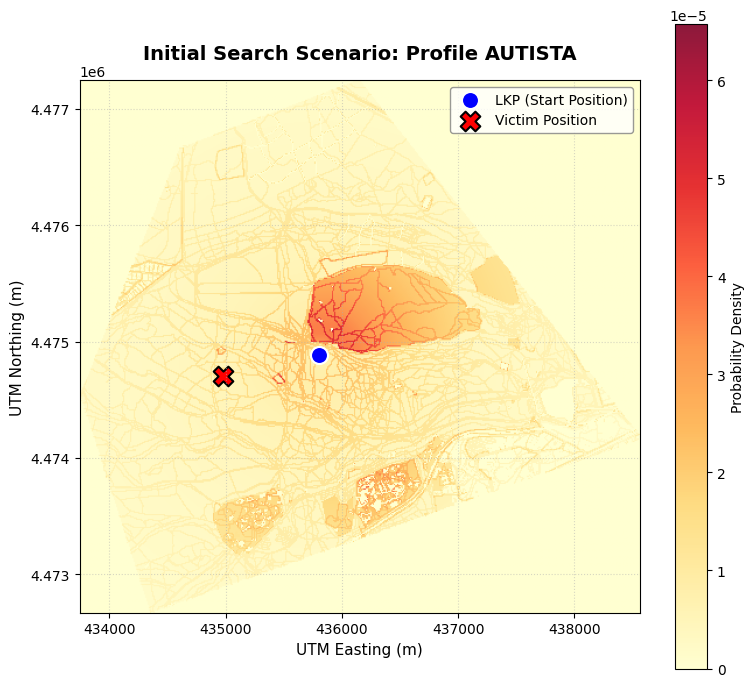

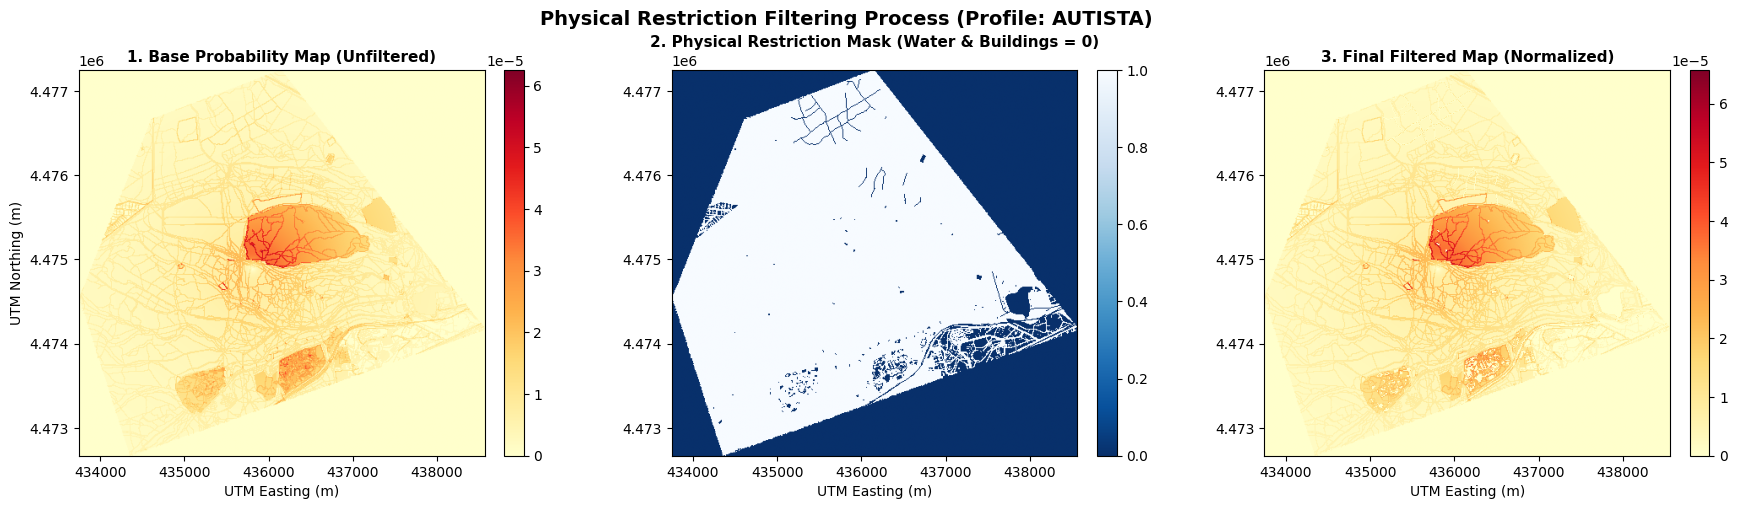

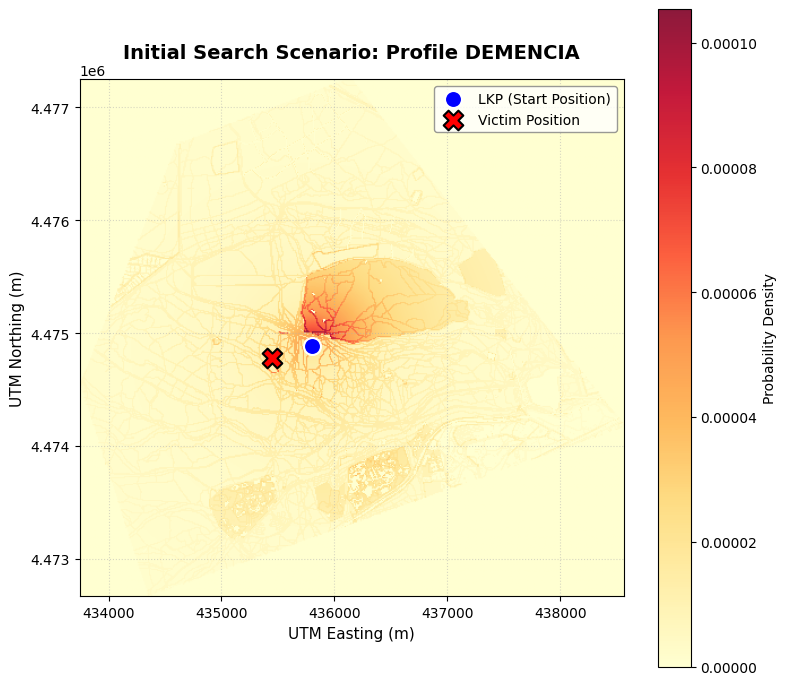

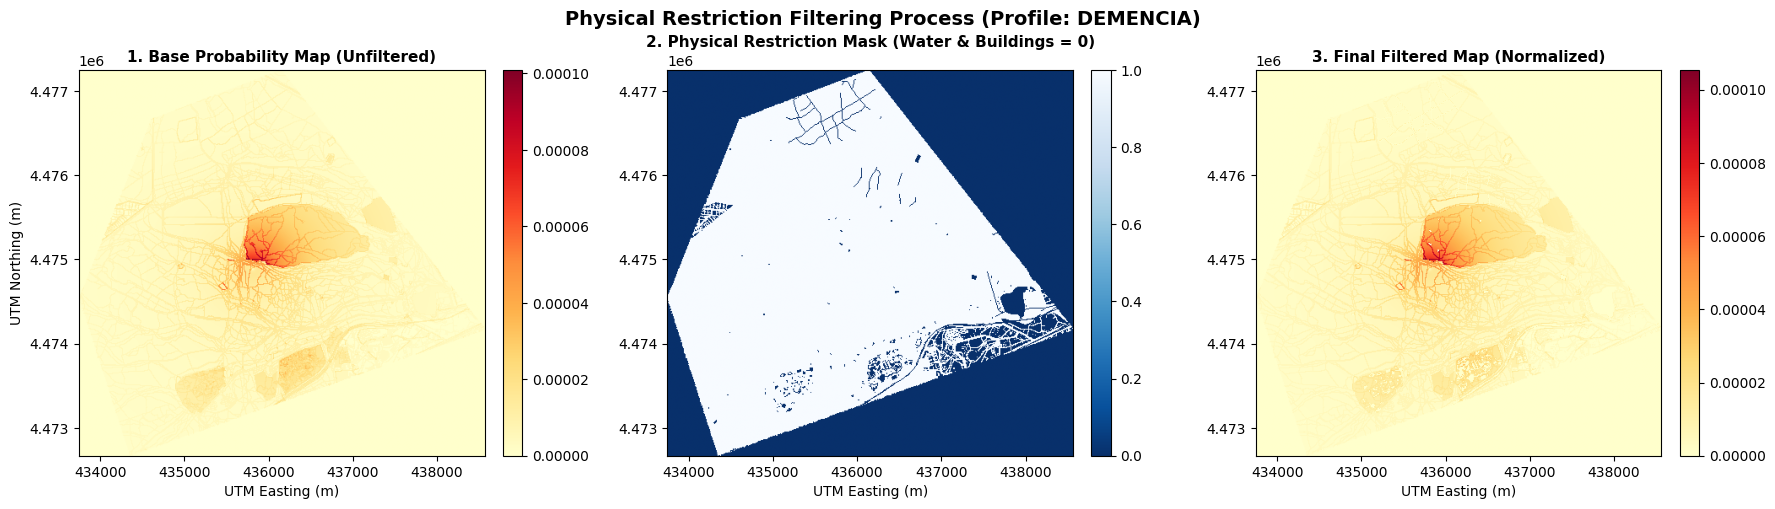

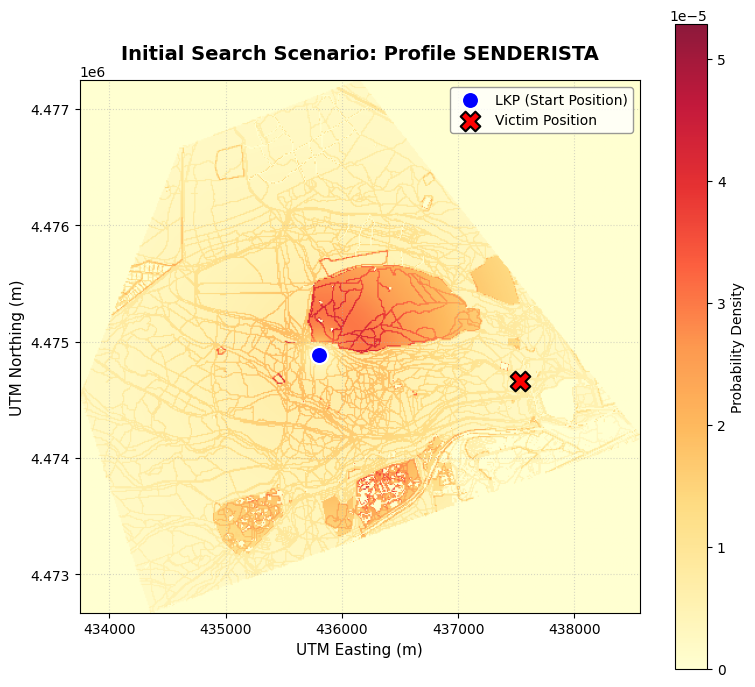

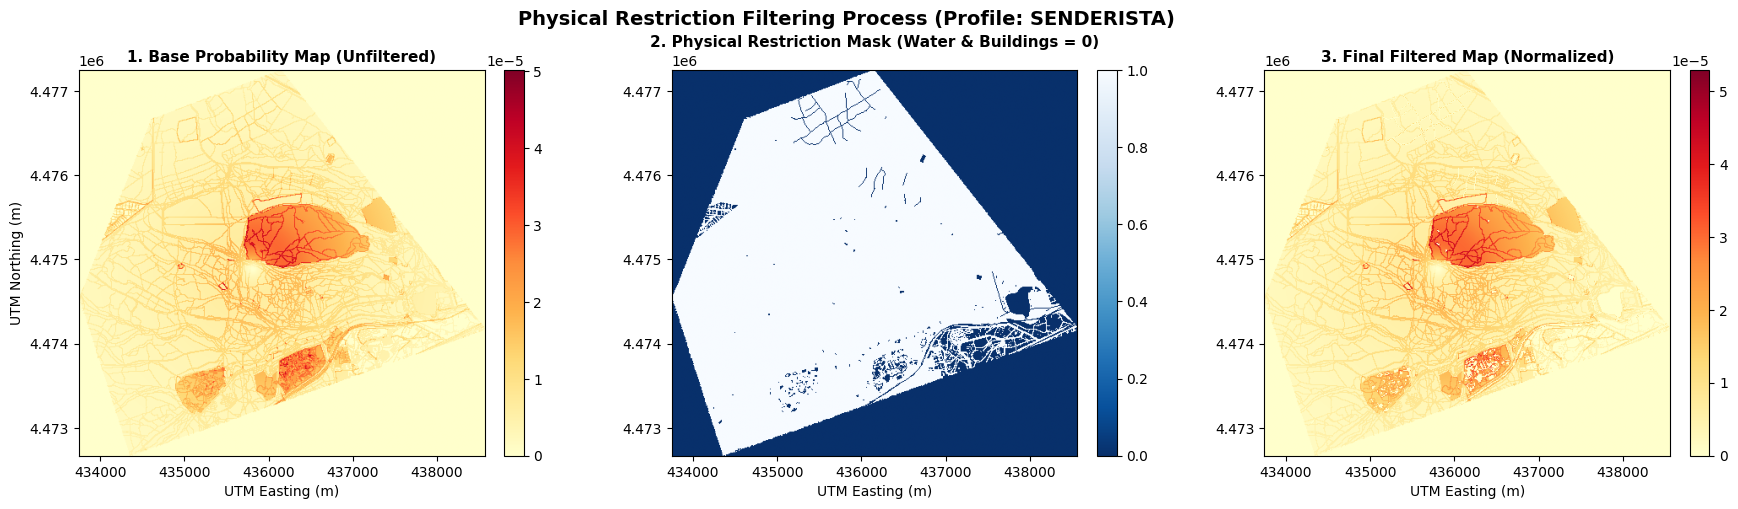

In [16]:
%matplotlib inline
import sys, importlib
import TFM_JC.scripts.visualizacion_pro as vis_pro
importlib.reload(vis_pro)

# Visualización de Setup y Validación del Entorno para los 3 perfiles
perfiles = ["autista", "demencia", "senderista"]
for perfil in perfiles:
    print(f"=== Generando Visualización de Setup/Filtro para: {perfil.upper()} ===")
    # 1. Visualización del Escenario Inicial
    vis_pro.plot_escenario_inicial(perfil=perfil, algoritmo="ABC", semilla=1, output_path=f"TFM_JC/resultados/graficas/escenario_inicial_{perfil}.png")
    # 2. Visualización del Filtro de Restricciones (Antes, Máscara y Después)
    vis_pro.plot_filtro_restricciones(perfil=perfil, output_path=f"TFM_JC/resultados/graficas/filtro_restricciones_{perfil}.png")


### Selector de Capas e Interactividad (ipywidgets)

A continuación, se presenta el panel interactivo solicitado para configurar en tiempo real las ponderaciones de las capas físicas y los radios estadísticos de la víctima. 
Elige un perfil predefinido del menú desplegable o selecciona **Personalizado** para mover los deslizadores de los pesos a tu gusto. Al hacer clic en **Generar y Mostrar Mapa**, se descargará la cartografía OSM correspondiente de la Casa de Campo (si no está en caché) y se calculará y visualizará el mapa de calor resultante.

In [14]:
%matplotlib inline
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from TFM_JC.scripts.utils_pipeline import generar_mapa_perfil, CASA_DE_CAMPO_POLY
import sarenv.utils.lost_person_behavior as lpb

# 1. Definición de perfiles y constantes estadísticas sincronizadas con el Manual de Koester
PRESETS = {
    "Autista": {
        "weights": {
            "structure": 0.45, "road": 0.18, "water": 0.09, "brush": 0.09, 
            "woodland": 0.09, "field": 0.09, "scrub": 0.0, "linear": 0.0, 
            "drainage": 0.0, "rock": 0.0
        },
        "radii": [0.6, 1.6, 3.7, 15.2]
    },
    "Demencia": {
        "weights": {
            "structure": 0.20, "road": 0.18, "woodland": 0.17, "field": 0.14,
            "linear": 0.09, "drainage": 0.09, "water": 0.07, "scrub": 0.06, 
            "brush": 0.0, "rock": 0.0
        },
        "radii": [0.3, 1.0, 2.4, 12.8]
    },
    "Senderista": {
        "weights": {
            "linear": 0.25, "field": 0.14, "structure": 0.13, "road": 0.13,
            "drainage": 0.12, "water": 0.08, "woodland": 0.07, "rock": 0.04, 
            "brush": 0.03, "scrub": 0.02
        },
        "radii": [0.6, 1.8, 3.2, 9.9]
    },
    "Personalizado": {
        "weights": {
            "water": 0.10, "structure": 0.10, "road": 0.10, "brush": 0.10, 
            "scrub": 0.10, "woodland": 0.10, "field": 0.10, "linear": 0.10, 
            "drainage": 0.10, "rock": 0.10
        },
        "radii": [0.5, 1.5, 3.0, 10.0]
    }
}

# 2. Creación de los widgets limpios sin anchos forzados que provoquen scrollbars
perfil_dropdown = widgets.Dropdown(
    options=["Autista", "Demencia", "Senderista", "Personalizado"],
    value="Autista",
    description="Perfil:"
)

feature_names = ["water", "structure", "road", "brush", "scrub", "woodland", "field", "linear", "drainage", "rock"]
sliders = {}
for name in feature_names:
    sliders[name] = widgets.FloatSlider(
        value=PRESETS["Autista"]["weights"].get(name, 0.0),
        min=0.0,
        max=1.0,
        step=0.01,
        description=name.capitalize() + ":",
        continuous_update=False
    )

radii_inputs = []
labels = ["25% (Small) km:", "50% (Medium) km:", "75% (Large) km:", "95% (XLarge) km:"]
for i in range(4):
    radii_inputs.append(widgets.FloatText(
        value=PRESETS["Autista"]["radii"][i],
        description=labels[i]
    ))

button = widgets.Button(
    description="Generar y Mostrar Mapa",
    button_style="success",
    tooltip="Generar el mapa de calor con los pesos seleccionados",
    icon="check"
)

output_plot = widgets.Output()

# 3. Lógica de interactividad y actualización
def on_profile_change(change):
    p = change["new"]
    weights = PRESETS[p]["weights"]
    radii = PRESETS[p]["radii"]
    
    for name in feature_names:
        sliders[name].value = weights.get(name, 0.0)
        sliders[name].disabled = (p != "Personalizado")
        
    for i in range(4):
        radii_inputs[i].value = radii[i]
        radii_inputs[i].disabled = (p != "Personalizado")

perfil_dropdown.observe(on_profile_change, names="value")

def generate_heatmap_interactivo(b):
    with output_plot:
        clear_output(wait=True)
        print("Cargando y procesando mapa real de Casa de Campo... (Esto puede tomar unos segundos)")
        
        pesos = {name: sliders[name].value for name in feature_names}
        radii = [r.value for r in radii_inputs]
        
        nombre_perfil = perfil_dropdown.value.lower()
        
        generar_mapa_perfil(nombre_perfil, pesos, radii)
        
        output_dir = f"TFM_JC/resultados/casa_de_campo_{nombre_perfil}"
        heatmap_path = os.path.join(output_dir, "heatmap.npy")
        
        if os.path.exists(heatmap_path):
            heatmap = np.load(heatmap_path)
            
            from IPython import get_ipython
            ipy = get_ipython()
            if ipy is not None:
                ipy.run_line_magic('matplotlib', 'inline')
            
            fig, ax = plt.subplots(figsize=(8, 7))
            im = ax.imshow(heatmap, cmap="YlOrRd", origin="lower")
            ax.set_title(f"Mapa de Calor Interactivo: {perfil_dropdown.value.upper()}", fontsize=14, fontweight="bold")
            ax.axis("off")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            plt.tight_layout()
            display(fig)
            plt.close(fig)
            print(f"Mapa completado y filtrado guardado en: {output_dir}")
        else:
            print("Error: No se pudo generar el archivo de mapa de calor (.npy).")

button.on_click(generate_heatmap_interactivo)

# Layout fluido limpio sin anchos forzados
left_column = widgets.VBox([
    perfil_dropdown,
    widgets.HTML("<b>Pesos de Capas (OpenStreetMap):</b>"),
    widgets.VBox([sliders[name] for name in feature_names]),
    button
])

right_column = widgets.VBox([
    widgets.HTML("<b>Radios Acumulados (km):</b>"),
    widgets.VBox(radii_inputs)
])

controls_box = widgets.HBox([left_column, right_column])
display(widgets.HBox([controls_box, output_plot]))


### Visualización de Validación: Mapas de Calor en Paralelo

Cargamos los archivos `.npy` generados y los representamos uno al lado del otro para corroborar visualmente cómo cambia la distribución de probabilidad espacial en la Casa de Campo en función de las prioridades del perfil de comportamiento de la víctima (Autista, Demencia, Senderista).

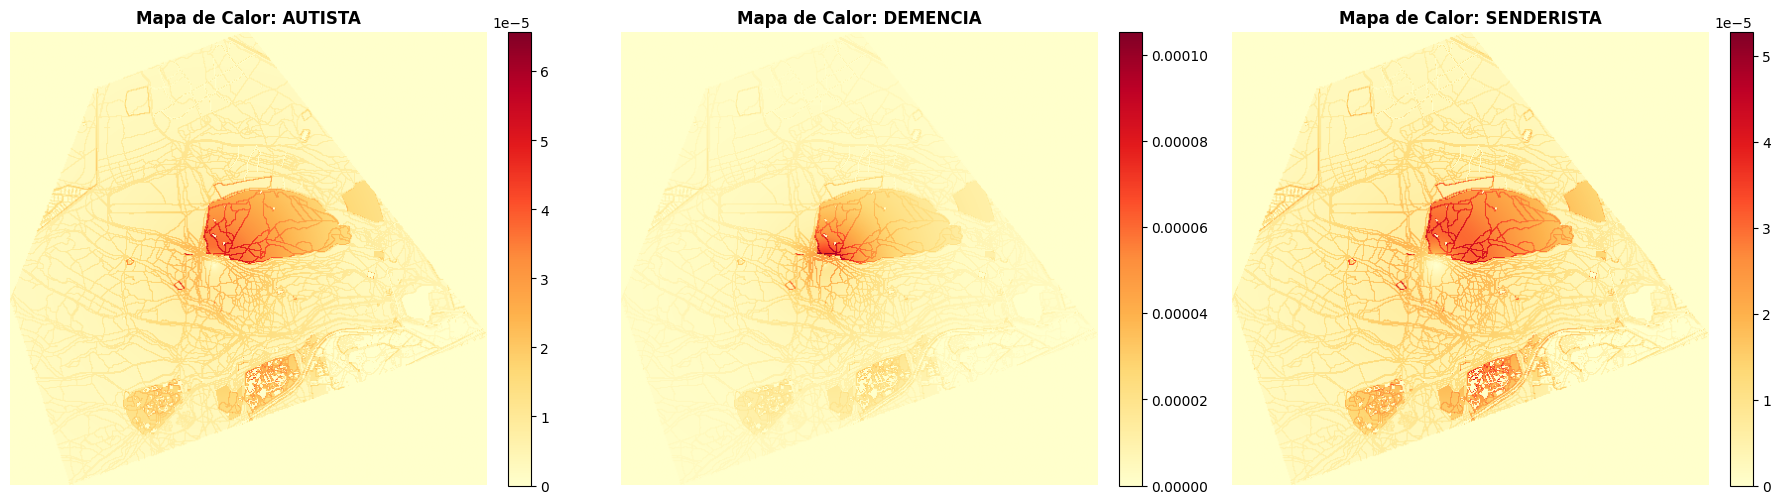

In [15]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Configuración de figura en paralelo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
perfiles = ["autista", "demencia", "senderista"]

for i, perfil in enumerate(perfiles):
    heatmap_path = f"TFM_JC/resultados/casa_de_campo_{perfil}/heatmap.npy"
    if os.path.exists(heatmap_path):
        heatmap = np.load(heatmap_path)
        im = axes[i].imshow(heatmap, cmap="YlOrRd", origin="lower")
        axes[i].set_title(f"Mapa de Calor: {perfil.upper()}", fontsize=12, fontweight="bold")
        axes[i].axis("off")
        fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
    else:
        axes[i].text(0.5, 0.5, f"No se encontró\n{perfil}", ha='center', va='center')
        axes[i].set_title(f"{perfil.upper()} (Faltante)")
        
plt.tight_layout()
plt.show();

## Fase 4: El Middleware (Traducción de Mapas a Rejillas Locales de MTS)

El simulador **MTS** opera sobre un sistema de coordenadas discreto local $(X, Y)$ con origen $[0,0]$ en la esquina inferior izquierda. Por lo tanto, el middleware `generar_json_real.py` traduce las coordenadas UTM globales (proyectadas desde latitud y longitud) a celdas discretas de la rejilla, calculando de forma precisa la ubicación local del LKP (*Last Known Position* / Punto de Inicio) para los agentes y configurando los parámetros del dron.

### Resolución Espacial de la Rejilla de Búsqueda (Celda de $10\text{ m}$)
El dominio de búsqueda espacial se discretiza utilizando el parámetro `meter_per_bin = 10` en la Fase 4.
- **Área Física por Celda:** Cada celda representa un cuadrado en la rejilla de $10\text{ m} 	imes 10\text{ m} = 100\text{ m}^2$ en el mundo real.
- **Justificación:** Esta resolución proporciona el equilibrio óptimo entre:
  1. *Precisión Física:* Permite capturar correctamente caminos, redes de carreteras y masas de agua estrechas (como los arroyos de la Casa de Campo o los bordes del lago), elementos que influyen fuertemente en el comportamiento de la víctima.
  2. *Rendimiento Computacional:* Minimiza el tamaño de la matriz de la rejilla ($458 \times 481$ celdas) para permitir bucles rápidos de Montecarlo sin saturar la memoria RAM.

In [3]:
from TFM_JC.scripts.utils_pipeline import ejecutar_middleware

# Ejecutar para los 3 perfiles
ejecutar_middleware("autista")
ejecutar_middleware("demencia")
ejecutar_middleware("senderista")

print("=== Fase 2 completada: Ficheros JSON de configuración listos para MTS ===")


Ejecutando middleware para: escenario_autista...
¡JSON generado correctamente en!: TFM_JC/resultados/casa_de_campo_autista/escenario_autista.json
Ejecutando middleware para: escenario_demencia...
¡JSON generado correctamente en!: TFM_JC/resultados/casa_de_campo_demencia/escenario_demencia.json
Ejecutando middleware para: escenario_senderista...
¡JSON generado correctamente en!: TFM_JC/resultados/casa_de_campo_senderista/escenario_senderista.json
=== Fase 2 completada: Ficheros JSON de configuración listos para MTS ===


# Visualización del mapa de creencias en coordenadas locales

Para validar la correcta transformación de coordenadas y visualizar el mapa de creencias que utilizará MTS, representamos lado a lado el mapa de calor original de SAREnv (en coordenadas UTM) y el mapa de rejilla traducido para MTS (en coordenadas locales). La estrella roja representa la **posición de inicio/LKP del dron**. Si la orientación del mapa y la posición del LKP coinciden perfectamente en ambos paneles, la transformación geométrica queda validada.

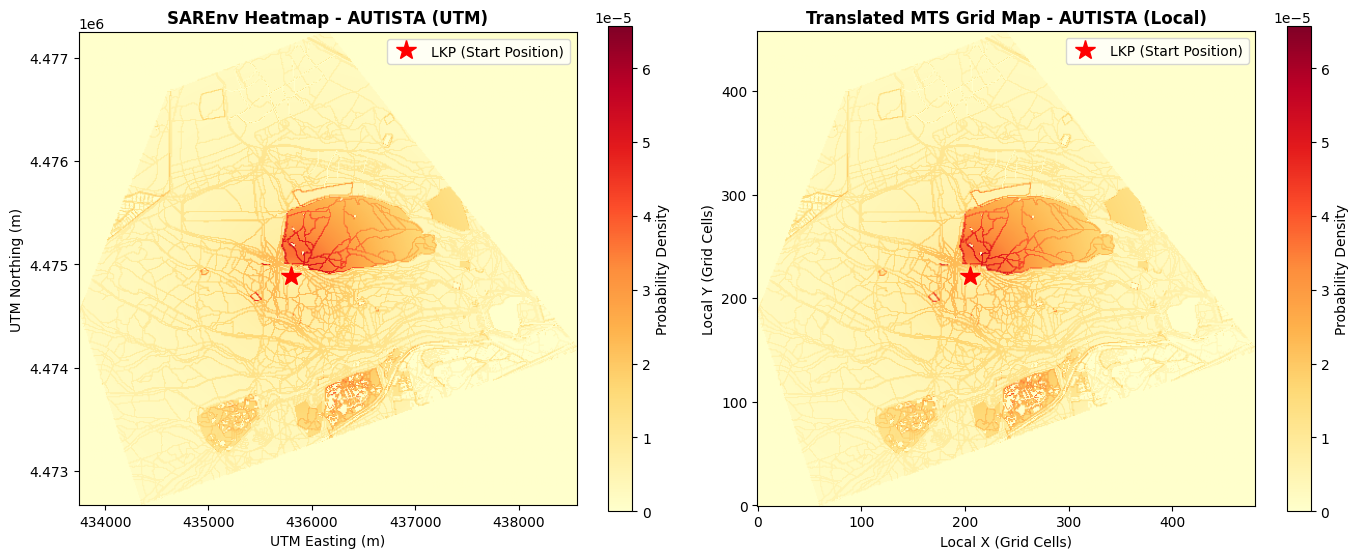

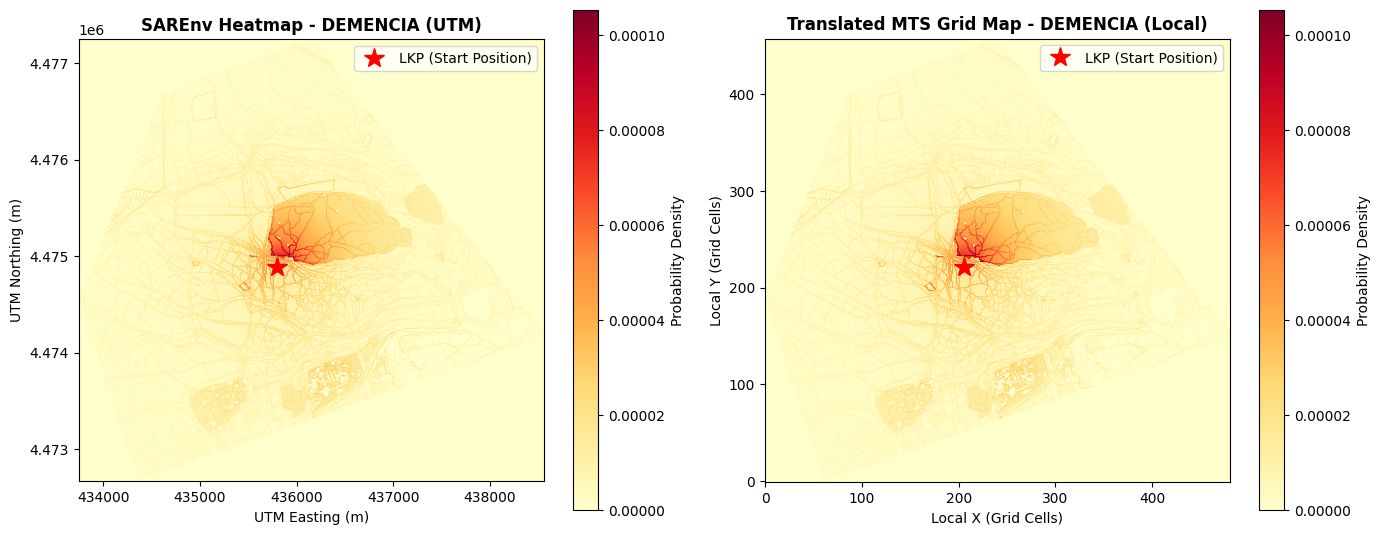

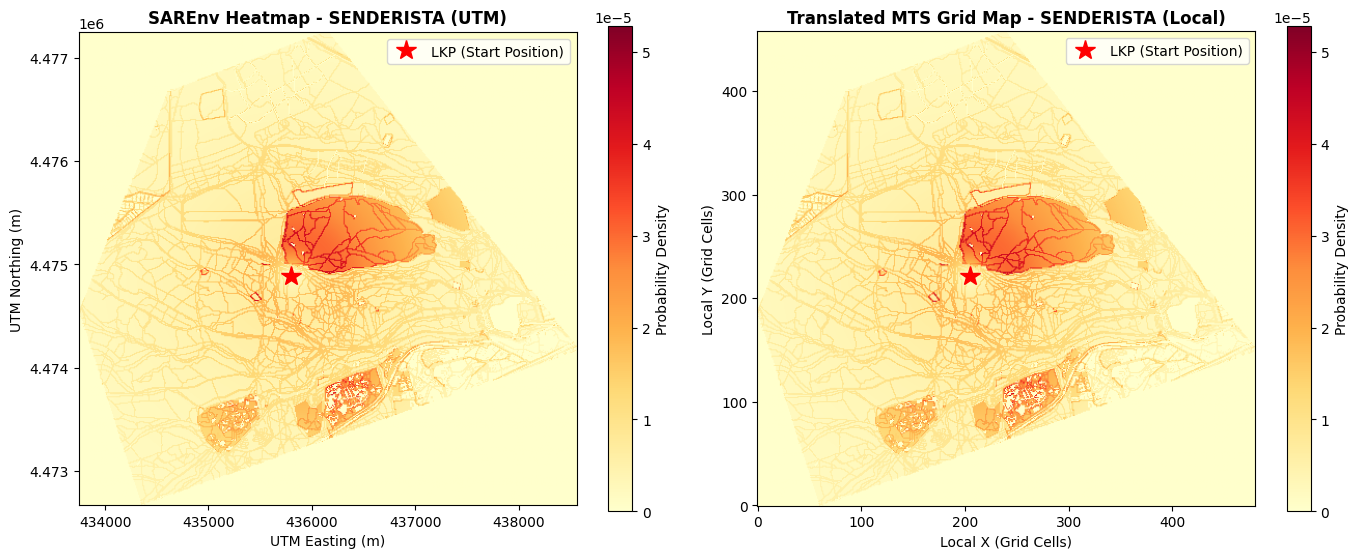

In [8]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from pyproj import Proj

# Profiles to validate
perfiles = ["autista", "demencia", "senderista"]

for perfil in perfiles:
    output_dir = f"TFM_JC/resultados/casa_de_campo_{perfil}"
    heatmap_sarenv_path = os.path.join(output_dir, "heatmap.npy")
    scenario_json_path = os.path.join(output_dir, f"escenario_{perfil}.json")
    heatmap_mts_path = os.path.join(output_dir, f"escenario_{perfil}.npy")
    
    if not (os.path.exists(heatmap_sarenv_path) and os.path.exists(scenario_json_path) and os.path.exists(heatmap_mts_path)):
        print(f"Skipping {perfil}: dataset or middleware files not found.")
        continue
        
    heatmap_sarenv = np.load(heatmap_sarenv_path)
    heatmap_mts = np.load(heatmap_mts_path)
    
    with open(os.path.join(output_dir, "features.geojson"), "r", encoding="utf-8") as f:
        meta = json.load(f)
    bounds = meta["bounds"]
    center_point = meta["center_point"]
    
    lon, lat = center_point
    zone = int((lon + 180) / 6) + 1
    epsg = f"EPSG:326{zone}" if lat >= 0 else f"EPSG:327{zone}"
    proj_utm = Proj(epsg)
    lkp_utm_x, lkp_utm_y = proj_utm(lon, lat)
    
    with open(scenario_json_path, "r", encoding="utf-8") as f:
        scen_data = json.load(f)
    lkp_local = scen_data["indicios"][0]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
    
    # 1. SAREnv Heatmap (UTM)
    extent_correct = [bounds[0], bounds[2], bounds[1], bounds[3]]
    im1 = ax1.imshow(heatmap_sarenv, origin="lower", extent=extent_correct, cmap="YlOrRd")
    ax1.plot(lkp_utm_x, lkp_utm_y, "r*", markersize=15, label="LKP (Start Position)")
    ax1.set_title(f"SAREnv Heatmap - {perfil.upper()} (UTM)", fontsize=12, fontweight="bold")
    ax1.set_xlabel("UTM Easting (m)", fontsize=10)
    ax1.set_ylabel("UTM Northing (m)", fontsize=10)
    ax1.legend(loc="upper right")
    fig.colorbar(im1, ax=ax1, label="Probability Density")
    
    # 2. MTS Local Grid Map (Local)
    im2 = ax2.imshow(heatmap_mts, origin="lower", cmap="YlOrRd")
    ax2.plot(lkp_local[0], lkp_local[1], "r*", markersize=15, label="LKP (Start Position)")
    ax2.set_title(f"Translated MTS Grid Map - {perfil.upper()} (Local)", fontsize=12, fontweight="bold")
    ax2.set_xlabel("Local X (Grid Cells)", fontsize=10)
    ax2.set_ylabel("Local Y (Grid Cells)", fontsize=10)
    ax2.legend(loc="upper right")
    fig.colorbar(im2, ax=ax2, label="Probability Density")
    
    plt.tight_layout()
    plt.show()


## Fase 5: Lanzamiento de Simulaciones Masivas en MTS

Para analizar la variabilidad estadística, ejecutamos **50 simulaciones independientes (semillas 0-49)** para cada perfil (Autista, Demencia, Senderista) y cada algoritmo de búsqueda:
1. **Greedy (Voraz Heurístico)**
2. **ACO (Optimización por Colonia de Hormigas)**
3. **ABC (Colonia de Abejas Artificiales)**
4. **BHA (Algoritmo de Agujero Negro)**

     "El script modifica dinámicamente los parámetros \"algoritmo_busqueda\" y \"semilla\" en el JSON correspondiente y ejecuta `bf-busqueda.py` con la animación desactivada (`\"dibujar_animacion\": False`) para acelerar el procesamiento headless."

In [4]:
import json
import os
import sys
import subprocess

# ==============================================================================
# CONFIGURACIÓN GLOBAL DE PARÁMETROS DEL BENCHMARK (MONTECARLO MASIVO)
# ==============================================================================
num_semillas = 50             # Número de ejecuciones independientes por caso (0-49)
bateria_pasos = 1000          # Batería o límite de pasos por vuelo
num_drones = 1                # Número de agentes drones

# MODO DE POSICIONAMIENTO DEL OBJETIVO (VÍCTIMA)
# goal_pos = None             # MODO ALEATORIO: Muestreo probabilístico según el heatmap (Recomendado)
# goal_pos = [103, 132]       # MODO FIJO: Víctima estática en coordenadas locales específicas (ej: Zoo)
goal_pos = None

# PARÁMETROS DEL SENSOR (CÁMARA)
pdmax = 0.8                   # Probabilidad máxima de detección
dmax = 2.1                    # Rango máximo de detección en celdas (25m de radio)
sigma = 0.7                   # Caída exponencial de sensibilidad
# ==============================================================================

MTS_DIR = os.getcwd()

from TFM_JC.scripts.utils_pipeline import lanzar_benchmark_simulaciones

# Lanzar el benchmark con los parámetros configurados arriba
lanzar_benchmark_simulaciones(
    semillas_count=num_semillas,
    bateria_pasos=bateria_pasos,
    num_drones=num_drones,
    pdmax=pdmax,
    dmax=dmax,
    sigma=sigma,
    goal_pos=goal_pos
)
print("\n=== Fase 5 completada: Simulaciones masivas finalizadas. ===")


Iniciando benchmark masivo en c:\Users\juanc\Desktop\TFM\TFM-Juan Carlos\Software\framwork-MTS\MTS-UncertainEnvironment-Algoritmos-bioinspirados.
Total de ejecuciones planeadas: 900\n
Iniciando simulaciones para el Perfil: AUTISTA
-> Ejecutando algoritmo: voraz-heur...
   Completadas las 50 semillas para voraz-heur.
-> Ejecutando algoritmo: ACO...
   Completadas las 50 semillas para ACO.
-> Ejecutando algoritmo: ABC...
   Completadas las 50 semillas para ABC.
-> Ejecutando algoritmo: BHA...
   Completadas las 50 semillas para BHA.
-> Ejecutando algoritmo: lawnmower...
   Completadas las 50 semillas para lawnmower.
-> Ejecutando algoritmo: expanding_sq...
   Completadas las 50 semillas para expanding_sq.
Iniciando simulaciones para el Perfil: DEMENCIA
-> Ejecutando algoritmo: voraz-heur...
   Completadas las 50 semillas para voraz-heur.
-> Ejecutando algoritmo: ACO...
   Completadas las 50 semillas para ACO.
-> Ejecutando algoritmo: ABC...
   Completadas las 50 semillas para ABC.
-> Eje

## Fase 6: Siembra de Víctimas de Montecarlo con Restricciones Geográficas

Para evaluar el desempeño científico, sembramos **1000 posiciones virtuales de víctimas** por perfil. Hacemos dos siembras distintas:
1. **Búsqueda Informada:** Posiciones generadas mediante muestreo probabilístico del heatmap bayesiano. Las víctimas aparecen en zonas de alta probabilidad estadística (ej. cerca de estructuras y lagos para el perfil Autista).
2. **Búsqueda Ciega (Línea de Base):** Posiciones distribuidas de forma totalmente uniforme por el polígono de la Casa de Campo.

**Restricciones de Transitabilidad a Pie (Filtros Físicos):** El generador realiza un filtrado espacial por índice geográfico (`sindex`) descartando cualquier posición que caiga dentro de polígonos de agua profunda (`water`) o edificaciones sólidas (`structure`) para evitar víctimas virtuales ahogadas o atrapadas en muros.

In [5]:
from TFM_JC.scripts.utils_pipeline import generar_y_guardar_victimas_montecarlo

# Generar para los 3 escenarios
generar_y_guardar_victimas_montecarlo("autista")
generar_y_guardar_victimas_montecarlo("demencia")
generar_y_guardar_victimas_montecarlo("senderista")

print("=== Fase 4 completada: Siembras de Montecarlo listas para evaluación ===")


Perfil AUTISTA: 1000 víctimas informadas y 1000 ciegas generadas con éxito.
Perfil DEMENCIA: 1000 víctimas informadas y 1000 ciegas generadas con éxito.
Perfil SENDERISTA: 1000 víctimas informadas y 1000 ciegas generadas con éxito.
=== Fase 4 completada: Siembras de Montecarlo listas para evaluación ===


In [ ]:
from TFM_JC.scripts.utils_pipeline import evaluar_todas_las_pruebas

df_eval = evaluar_todas_las_pruebas()
df_eval.head(10)
